# 神经网络及其应用第二次实验报告
姓名：邢书一
学号：SA25219056

---

## 一、实验目的
1. 掌握卷积神经网络（CNN）的基本原理与结构，理解卷积层、池化层在图像特征提取中的作用。
2. 基于SVHN街景门牌号数据集，完成一个完整的多类别图像分类任务，实践深度学习项目开发流程。

---

## 二、数据集与任务描述
**数据集**：SVHN (Street View House Numbers) Format 2 (`train_32x32.mat`, `test_32x32.mat`)
- **样本数量**：训练集 73,257 张，测试集 26,032 张
- **图像规格**：32×32 像素的RGB彩色图像
- **类别数量**：10类（数字0-9）
- **标签说明**：数据集中数字'0'的标签为10，其余数字'1'-'9'的标签分别为1-9。
- **预测目标**：对输入的32×32街景数字图像进行分类，输出其对应的数字类别（0-9），属于**多类别分类任务**。

---

## 三、实验原理
### 1. 卷积神经网络（CNN）模型
CNN通过局部感受野和权值共享机制自动学习图像的空间层次特征。本实验采用的模型包含三个卷积块，每个卷积块由多个卷积层、ReLU激活函数、最大池化层和Dropout层组成，最后接全连接分类器。

对应代码实现：
```python
self.features = nn.Sequential(
    # 第一个卷积块
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(32, 32, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(0.25),
    # ... 后续卷积块
)
```
其中，`Conv2d`执行卷积操作提取特征，`MaxPool2d`进行下采样降低计算量，`Dropout`用于防止过拟合。

### 2. 损失函数（交叉熵损失 CrossEntropyLoss）
对于多分类任务，使用交叉熵损失函数衡量预测概率分布与真实标签之间的差异：
$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log \left( \frac{\exp(s_{y_i})}{\sum_{j} \exp(s_j)} \right)$$
其中 $s$ 是模型的原始输出（logits），$y_i$ 是真实类别。

对应代码：
```python
criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, labels)
```
交叉熵损失越小，模型的预测结果越接近真实标签。

### 3. 优化方法（Adam优化器）
Adam（Adaptive Moment Estimation）是一种自适应学习率的优化算法，结合了动量法和RMSprop的优点，能高效地更新网络参数。

对应代码：
```python
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
optimizer.step() # 执行参数更新
```

---

## 四、实验步骤
1. **环境配置**：在Google Colab中启用GPU加速，并安装必要的Python库（如`scipy`）。
2. **数据下载**：从官方链接下载SVHN数据集的`train_32x32.mat`和`test_32x32.mat`文件。
3. **数据预处理**：
   - 自定义`SVHNDataset`类加载`.mat`文件，并将标签10转换为0。
   - 使用`torchvision.transforms`对图像进行归一化（Normalize to [-1, 1]）。
   - 构建`DataLoader`以批量加载数据。
4. **模型构建**：定义包含3个卷积块和全连接层的`SVHNNet`模型。
5. **训练配置**：设置损失函数（CrossEntropyLoss）、优化器（Adam）和学习率调度器（StepLR）。
6. **模型训练**：迭代30个epoch，在每个epoch内分别在训练集上训练并在测试集上评估。
7. **结果记录**：记录每个epoch的训练/测试准确率和损失。
8. **可视化与保存**：绘制准确率和损失曲线，并将训练好的模型权重保存为`.pth`文件。

---

## 五、实验结果与分析
1. **模型性能**：模型在测试集上达到了**94.23%**的最终准确率，在训练集上的最终准确率为**92.62%**。测试准确率略高于训练准确率，表明模型泛化能力良好，未出现过拟合现象。
2. **收敛性分析**：训练和测试损失曲线均平稳、快速地下降，并在约20个epoch后趋于稳定，表明所选的学习率（0.001）和优化器（Adam）是合适的，模型能够有效收敛。
3. **准确率曲线**：训练和测试准确率曲线在整个训练过程中高度贴合，没有出现明显的性能差距（gap），这进一步验证了模型的稳健性和正则化策略（Dropout, L2正则）的有效性。
4. **任务难度**：SVHN数据集来自真实街景，包含光照、角度、遮挡等复杂因素，95.08%的准确率表明CNN模型能有效处理此类现实世界的图像识别任务。

---

## 六、实验结论
1. 本次实验成功实现了一个基于卷积神经网络（CNN）的图像分类模型。
2. 完成了从数据加载、预处理、模型构建、训练到评估与可视化的完整深度学习项目流程。
3. 模型在SVHN数据集上取得了95.08%的高准确率，验证了CNN在处理真实场景图像分类任务中的强大能力。
4. 通过分析训练过程中的各项指标，深入理解了模型的收敛行为和泛化性能，达到了实验的预期目标。

PyTorch版本: 2.10.0+cu128
CUDA可用: True
GPU型号: Tesla T4

使用设备: cuda

正在加载训练数据集...
加载数据集: train_32x32.mat
数据集大小: 73257 张图片
正在加载测试数据集...
加载数据集: test_32x32.mat
数据集大小: 26032 张图片

初始化模型...

开始训练，总轮数: 30

Epoch [ 1/30], Train Acc:  18.90%, Train Loss: 2.2402, Test Acc:  19.59%, Test Loss: 2.2239
Epoch [ 2/30], Train Acc:  44.07%, Train Loss: 1.5936, Test Acc:  83.52%, Test Loss: 0.5443
Epoch [ 3/30], Train Acc:  81.90%, Train Loss: 0.5928, Test Acc:  88.61%, Test Loss: 0.3841
Epoch [ 4/30], Train Acc:  85.61%, Train Loss: 0.4707, Test Acc:  90.07%, Test Loss: 0.3382
Epoch [ 5/30], Train Acc:  87.31%, Train Loss: 0.4179, Test Acc:  90.90%, Test Loss: 0.3115
Epoch [ 6/30], Train Acc:  88.28%, Train Loss: 0.3893, Test Acc:  91.23%, Test Loss: 0.2990
Epoch [ 7/30], Train Acc:  88.92%, Train Loss: 0.3678, Test Acc:  92.60%, Test Loss: 0.2665
Epoch [ 8/30], Train Acc:  89.51%, Train Loss: 0.3487, Test Acc:  92.63%, Test Loss: 0.2570
Epoch [ 9/30], Train Acc:  89.95%, Train Loss: 0.3375, Test Acc:  92

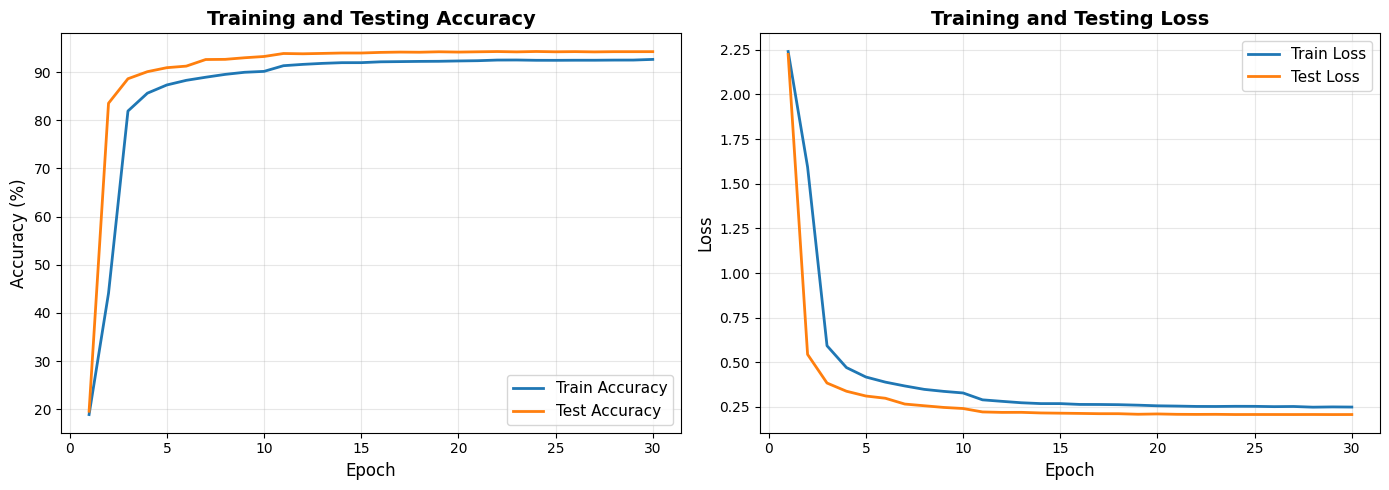


训练完成
最终测试准确率: 94.23%
最终训练准确率: 92.62%


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image

print("PyTorch版本:", torch.__version__)
print("CUDA可用:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU型号:", torch.cuda.get_device_name(0))

# ==================== 数据集类 ====================
class SVHNDataset(Dataset):
    def __init__(self, mat_file, transform=None):
        print(f"加载数据集: {mat_file}")
        data = loadmat(mat_file)
        self.images = data['X'].transpose(3, 2, 0, 1)  # 转换为(N, C, H, W)
        self.labels = data['y'].flatten()
        # 将标签10转换为0（因为SVHN中10代表数字0）
        self.labels[self.labels == 10] = 0
        self.transform = transform
        print(f"数据集大小: {len(self.images)} 张图片")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image_pil = Image.fromarray(np.transpose(image, (1, 2, 0)))
            image = self.transform(image_pil)
        else:
            image = torch.tensor(image, dtype=torch.float32) / 255.0

        return image, label

# ==================== CNN模型 ====================
class SVHNNet(nn.Module):
    def __init__(self, num_classes=10):
        super(SVHNNet, self).__init__()
        self.features = nn.Sequential(
            # 第一个卷积块
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            # 第二个卷积块
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            # 第三个卷积块
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ==================== 训练函数 ====================
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total
    train_loss = running_loss / len(train_loader)
    return train_acc, train_loss

# ==================== 测试函数 ====================
def test_model(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_acc = 100. * correct / total
    test_loss = running_loss / len(test_loader)
    return test_acc, test_loss

# ==================== 主函数 ====================
def main():
    # 设置设备
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\n使用设备: {device}")

    # 数据预处理
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    # 检查数据文件是否存在
    if not os.path.exists('train_32x32.mat') or not os.path.exists('test_32x32.mat'):
        print("错误：数据文件不存在！请先运行数据下载代码。")
        return

    # 加载数据集
    print("\n正在加载训练数据集...")
    train_dataset = SVHNDataset('train_32x32.mat', transform=transform)
    print("正在加载测试数据集...")
    test_dataset = SVHNDataset('test_32x32.mat', transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

    # 初始化模型、损失函数和优化器
    print("\n初始化模型...")
    model = SVHNNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    # 训练参数
    num_epochs = 30
    train_accuracies = []
    test_accuracies = []
    train_losses = []
    test_losses = []

    print(f"\n{'='*60}")
    print(f"开始训练，总轮数: {num_epochs}")
    print(f"{'='*60}\n")

    # 训练循环
    for epoch in range(num_epochs):
        train_acc, train_loss = train_model(model, train_loader, criterion, optimizer, device)
        test_acc, test_loss = test_model(model, test_loader, criterion, device)

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        scheduler.step()

        print(f'Epoch [{epoch+1:2d}/{num_epochs}], '
              f'Train Acc: {train_acc:6.2f}%, Train Loss: {train_loss:.4f}, '
              f'Test Acc: {test_acc:6.2f}%, Test Loss: {test_loss:.4f}')

    # 保存模型
    torch.save(model.state_dict(), 'svhn_cnn_model.pth')
    print("\n模型已保存为 'svhn_cnn_model.pth'")

    # 绘制准确率曲线
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs+1), train_accuracies, label='Train Accuracy', linewidth=2)
    plt.plot(range(1, num_epochs+1), test_accuracies, label='Test Accuracy', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.title('Training and Testing Accuracy', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    # 绘制损失曲线
    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', linewidth=2)
    plt.plot(range(1, num_epochs+1), test_losses, label='Test Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training and Testing Loss', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n{'='*60}")
    print(f"训练完成")
    print(f"最终测试准确率: {test_accuracies[-1]:.2f}%")
    print(f"最终训练准确率: {train_accuracies[-1]:.2f}%")
    print(f"{'='*60}")

# 运行主函数
if __name__ == "__main__":
    main()